In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")

X_train = pd.read_csv("../data/processed/X_train_binary.csv")
y_train = pd.read_csv("../data/processed/y_train_binary.csv").squeeze()

X_test = pd.read_csv("../data/processed/X_test_binary.csv")
y_test = pd.read_csv("../data/processed/y_test_binary.csv").squeeze()

best_xgb = joblib.load("../models/final_xgb_model.joblib")

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (202944, 21)
Test : (50736, 21)


In [2]:
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, y_proba), 4))

ROC-AUC: 0.8253
PR-AUC : 0.465


In [3]:
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(4).to_string(index=False))

 Threshold  Precision  Recall     F1
      0.20     0.2319  0.9580 0.3734
      0.25     0.2482  0.9406 0.3927
      0.30     0.2640  0.9178 0.4101
      0.35     0.2799  0.8936 0.4262
      0.40     0.2962  0.8630 0.4410
      0.45     0.3154  0.8280 0.4568
      0.50     0.3361  0.7871 0.4711
      0.55     0.3574  0.7346 0.4808
      0.60     0.3829  0.6783 0.4895
      0.65     0.4121  0.6089 0.4915
      0.70     0.4488  0.5238 0.4834


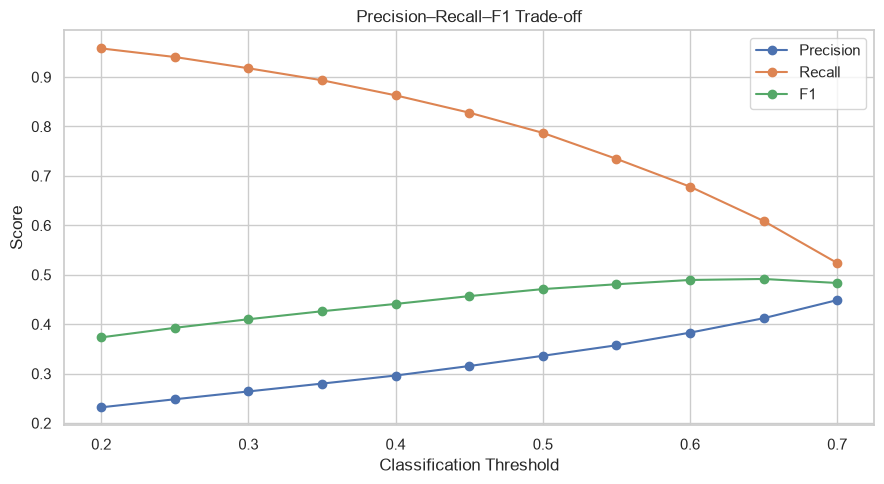

In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 Trade-off")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on F1:")
print(best_row)

Best threshold based on F1:
Threshold    0.650000
Precision    0.412123
Recall       0.608881
F1           0.491543
Name: 9, dtype: float64


In [6]:
default_threshold = 0.50
optimized_threshold = float(best_row["Threshold"])

y_pred_default = (
    y_proba >= default_threshold
).astype(int)

y_pred_optimized = (
    y_proba >= optimized_threshold
).astype(int)

comparison = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1"],
    
    "Threshold 0.50": [
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default)
    ],
    
    f"Optimized ({optimized_threshold:.2f})": [
        precision_score(y_test, y_pred_optimized),
        recall_score(y_test, y_pred_optimized),
        f1_score(y_test, y_pred_optimized)
    ]
})

print(comparison.round(4).to_string(index=False))

   Metric  Threshold 0.50  Optimized (0.65)
Precision          0.3361            0.4121
   Recall          0.7871            0.6089
       F1          0.4711            0.4915


In [7]:
print("=" * 60)
print("FINAL XGBOOST MODEL")
print("=" * 60)

print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")

print(f"\nOptimized threshold: {optimized_threshold:.2f}")

print(
    classification_report(
        y_test,
        y_pred_optimized,
        digits=4
    )
)

FINAL XGBOOST MODEL
ROC-AUC : 0.8253
PR-AUC  : 0.4650

Optimized threshold: 0.65
              precision    recall  f1-score   support

           0     0.9197    0.8375    0.8767     42741
           1     0.4121    0.6089    0.4915      7995

    accuracy                         0.8015     50736
   macro avg     0.6659    0.7232    0.6841     50736
weighted avg     0.8397    0.8015    0.8160     50736



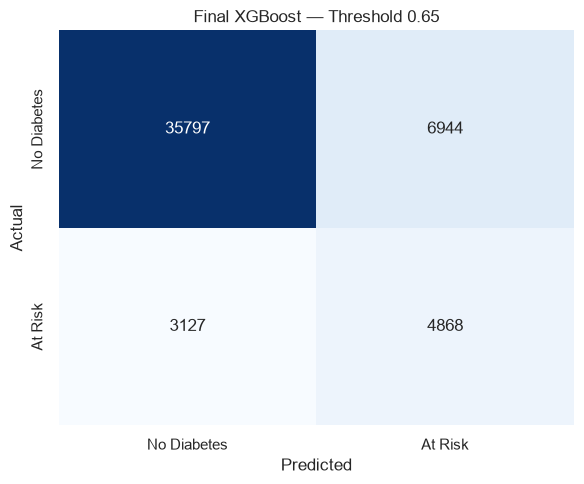

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred_optimized
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Diabetes", "At Risk"],
    yticklabels=["No Diabetes", "At Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Final XGBoost — Threshold {optimized_threshold:.2f}"
)

plt.tight_layout()
plt.show()

In [9]:
import json

final_config = {
    "threshold": optimized_threshold,
    "roc_auc": float(roc_auc_score(y_test, y_proba)),
    "pr_auc": float(average_precision_score(y_test, y_proba)),
    "precision": float(
        precision_score(y_test, y_pred_optimized)
    ),
    "recall": float(
        recall_score(y_test, y_pred_optimized)
    ),
    "f1": float(
        f1_score(y_test, y_pred_optimized)
    )
}

with open("../models/final_model_config.json", "w") as f:
    json.dump(final_config, f, indent=4)

print("Final model configuration saved.")
print(final_config)

Final model configuration saved.
{'threshold': 0.6499999999999999, 'roc_auc': 0.8252756897395819, 'pr_auc': 0.46499747287979626, 'precision': 0.41212326447680325, 'recall': 0.6088805503439649, 'f1': 0.4915433937496845}
